### 3.2 

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp


<Figure size 2160x720 with 0 Axes>

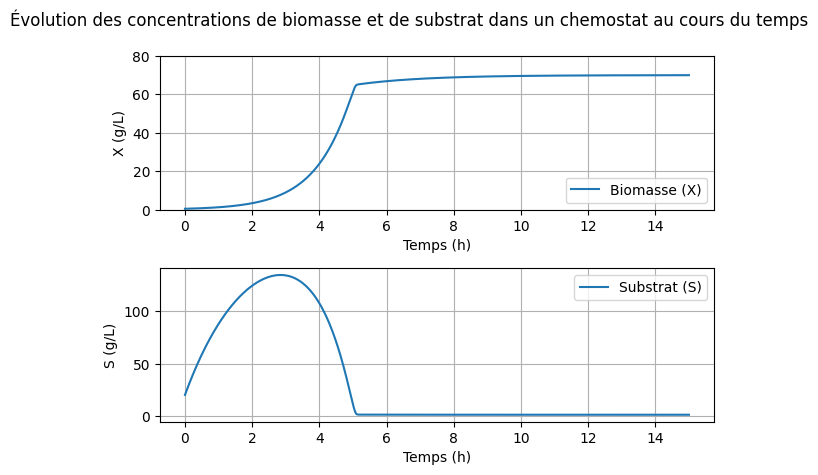

In [9]:
def bilans(t, x, p, u):
    [X, S] = x
    [V, mu_max, Ks, Yxs] = p
    [F, Sin] = u
    mu = mu_max * S / (Ks + S)
    dXdt = mu * X - (F / V) * X
    dSdt = - (1 / Yxs) * mu * X + (F / V) * (Sin - S)
    return [dXdt, dSdt]

#conditions initiales
p = [2.0, 1.5, 2.0, 0.352]
x0 = [0.5, 20]
u0 = [1 , 200]
t_sim = [0, 15]

#résolution des équations différentielles
sim = solve_ivp(bilans, t_sim, x0, method = 'RK45', args = (p, u0), max_step = 0.01)

#graphiques
plt.figure(figsize=(18, 6), dpi=120)
fig, axs = plt.subplots(nrows = 2, ncols = 1)
fig.suptitle('Évolution des concentrations de biomasse et de substrat dans un chemostat au cours du temps', fontsize=12)

axs[0].plot(sim.t, sim.y[0, :], label ='Biomasse (X)')
axs[0].set_xlabel('Temps (h)')
axs[0].set_ylabel('X (g/L)')
axs[0].legend(loc = 'lower right')
axs[0].set_ylim(0, 80)
axs[0].grid()

axs[1].plot(sim.t, sim.y[1, :], label ='Substrat (S)')
axs[1].set_xlabel('Temps (h)')
axs[1].set_ylabel('S (g/L)')
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()


Selon le graphique ci-haut, la concentration de biomasse dans le réacteur lorsque le système semble atteindre le régime permanent (après environs 10 heures d'opération) est d'environs 70 g/L. La concentration de substrat dans le réacteur semble avoir une valeure constante après seulement 5 heures d'opération, avec une concentration de 1 g/L. 

### 3.3
#### a)

In [10]:
#Conditions de régime permanent 
X , S = sim.y
print('Valeurs en regime permanent :')
print(f'X* = {X[-1]:.1f} g/L')
print(f'S* = {S[-1]:.1f} g/L')


Valeurs en regime permanent :
X* = 70.0 g/L
S* = 1.0 g/L


#### b)

<Figure size 2160x720 with 0 Axes>

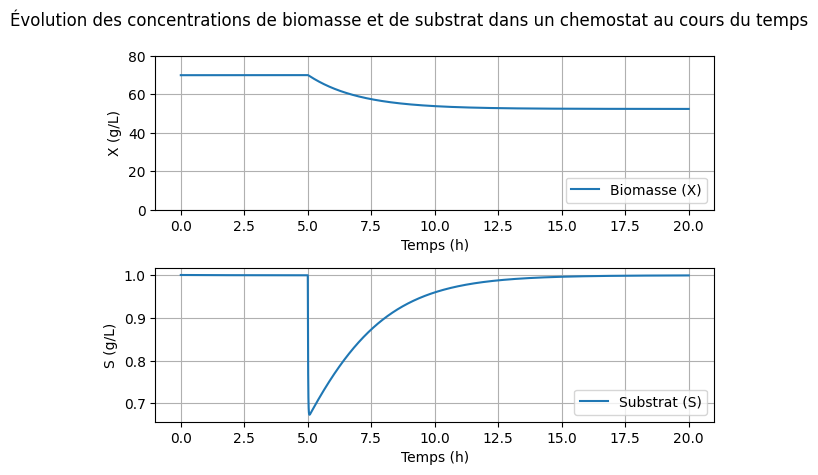

In [11]:
#Définir manipulation
def manip(t, x, p, t_changement):
    u = [F, Sin]
    if t < t_changement[0]:
        u = [F, Sin]
    else:
        u = [Fnew, Sinnew]
    return bilans(t, x, p, u)

#conditions initiales
p = [2.0, 1.5, 2.0, 0.352]
F = 1
Sin = 200
Fnew = 1
Sinnew = 150
x0 = [X[-1], S[-1]]
u0 = [F , Sin]
t_sim = [0, 20]
t_changement = [5]

#résolution des équations différentielles
sim33 = solve_ivp(manip, t_sim, x0, method = 'RK45', args = (p, t_changement), max_step = 0.01)

#graphiques
plt.figure(figsize=(18, 6), dpi=120)
fig, axs = plt.subplots(nrows = 2, ncols = 1)
fig.suptitle('Évolution des concentrations de biomasse et de substrat dans un chemostat au cours du temps', fontsize=12)

axs[0].plot(sim33.t, sim33.y[0, :], label ='Biomasse (X)')
axs[0].set_xlabel('Temps (h)')
axs[0].set_ylabel('X (g/L)')
axs[0].legend(loc = 'lower right')
axs[0].set_ylim(0, 80)
axs[0].grid()

axs[1].plot(sim33.t, sim33.y[1, :], label ='Substrat (S)')
axs[1].set_xlabel('Temps (h)')
axs[1].set_ylabel('S (g/L)')
axs[1].legend(loc = 'lower right')
axs[1].grid()

plt.tight_layout()
plt.show()

Après 5h d'opération, lorsque la concentration d'alimentation en substrat diminue à 150 g/L, on remarque que la concentration de biomasse dans le réacteur baisse lentement et peu, selon une courbe de décroissance exponentielle, pour atteindre une concentration constante d'environs 52 g/L en régime permanent. La concentration en substrat, elle, diminue beaucoup très rapidement dès l'atteinte des 5h d'opération. Elle va ensuite augmenter lentement selon une courbe de croissance exponentielle, pour atteindre une concentration constante de 1 g/L, soit la même valeur que la valeur initiale de concentration de substrat dans le réacteur. 

### 3.4

<Figure size 2160x720 with 0 Axes>

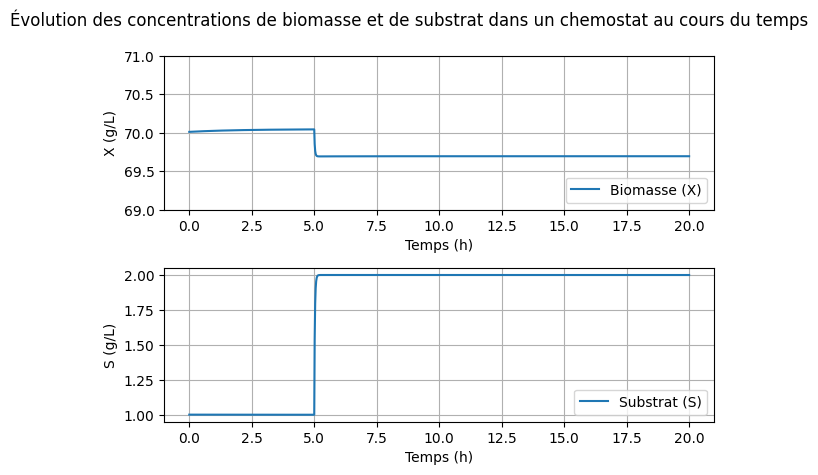

In [12]:
#conditions initiales
p = [2.0, 1.5, 2.0, 0.352]
F = 1
Sin = 200
Fnew = 1.5
Sinnew = 200
x0 = [X[-1], S[-1]]
u0 = [F , Sin]
t_sim = [0, 20]
t_changement = [5]

#résolution des équations différentielles
sim34 = solve_ivp(manip, t_sim, x0, method = 'RK45', args = (p, t_changement), max_step = 0.01)

#graphiques
plt.figure(figsize=(18, 6), dpi=120)
fig, axs = plt.subplots(nrows = 2, ncols = 1)
fig.suptitle('Évolution des concentrations de biomasse et de substrat dans un chemostat au cours du temps', fontsize=12)

axs[0].plot(sim34.t, sim34.y[0, :], label ='Biomasse (X)')
axs[0].set_xlabel('Temps (h)')
axs[0].set_ylabel('X (g/L)')
axs[0].legend(loc = 'lower right')
axs[0].set_ylim(69, 71)
axs[0].grid()

axs[1].plot(sim34.t, sim34.y[1, :], label ='Substrat (S)')
axs[1].set_xlabel('Temps (h)')
axs[1].set_ylabel('S (g/L)')
axs[1].legend(loc = 'lower right')
axs[1].grid()

plt.tight_layout()
plt.show()

Lorsque le débit d'entrée et de sortie du réacteur augmente à 1.5 m3/h après 5h d'opération, on peut remarquer que la concentration en biomasse dans le réacteur diminue très légèrement à environs 69 g/L, où le système atteint directement le régime permanent, rendant cette valeur constante pour le reste de l'opération. On peut aussi remarquer que la concentration en substrat dans le réacteur augmente légèrement à 2 g/L. Le système atteint directement le régime permanent, rendant cette valeur constante pour le reste de l'opération. 

### 3.5
#### a)

In [13]:
#Definition des variables symboliques
X, S = sp.symbols('X S')
Sin, F = sp.symbols('Sin F')
V, mu_max, Ks, Yxs = sp.symbols('V mu_max Ks Yxs')

mu = mu_max * S / (Ks + S)

#Systeme d’equations differentielles
dXdt = mu * X - (F / V) * X
dSdt = - (1 / Yxs) * mu * X + (F / V) * (Sin - S)

f = sp.Matrix([dXdt, dSdt])
x = sp.Matrix([X, S])
u = sp.Matrix([Sin, F])

#Calcul symbolique des matrices A et B
mat_A = sp.simplify(f.jacobian(x))
mat_B = sp.simplify(f.jacobian(u))

print("Matrice A- symbolique =")
sp.pprint(mat_A)

print("Matrice B- symbolique =")
sp.pprint(mat_B)

#Calcul numerique des matrices A et B
valeurs_num = {X: 70, S: 1,
                V: 2.0, mu_max: 1.5, Ks: 2.0, Yxs: 0.352,
                F: 1, Sin: 200}

mat_A_num = mat_A.subs(valeurs_num).evalf()
mat_B_num = mat_B.subs(valeurs_num).evalf()

print("Matrice A- numerique =")
sp.pprint(mat_A_num)

print("Matrice B- numerique =")
sp.pprint(mat_B_num)

Matrice A- symbolique =
⎡-F⋅(Ks + S) + S⋅V⋅μₘₐₓ       Ks⋅X⋅μₘₐₓ     ⎤
⎢──────────────────────       ─────────     ⎥
⎢      V⋅(Ks + S)                     2     ⎥
⎢                             (Ks + S)      ⎥
⎢                                           ⎥
⎢       -S⋅μₘₐₓ            F     Ks⋅X⋅μₘₐₓ  ⎥
⎢     ────────────       - ─ - ─────────────⎥
⎢     Yxs⋅(Ks + S)         V               2⎥
⎣                              Yxs⋅(Ks + S) ⎦
Matrice B- symbolique =
⎡     -X    ⎤
⎢0    ───   ⎥
⎢      V    ⎥
⎢           ⎥
⎢F  -S + Sin⎥
⎢─  ────────⎥
⎣V     V    ⎦
Matrice A- numerique =
⎡        0          23.3333333333333 ⎤
⎢                                    ⎥
⎣-1.42045454545455  -66.7878787878788⎦
Matrice B- numerique =
⎡ 0   -35.0⎤
⎢          ⎥
⎣0.5  99.5 ⎦


#### b)

<Figure size 2160x720 with 0 Axes>

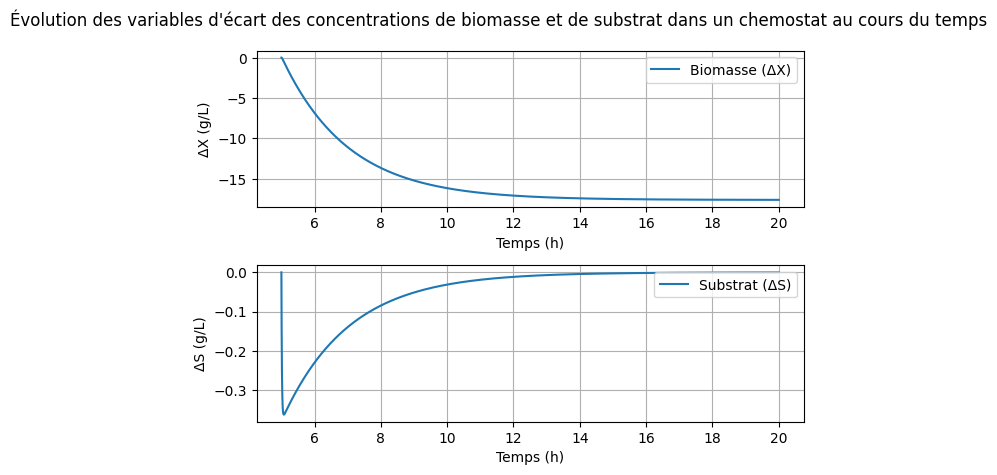

In [14]:
mat_A_np = np.asarray(mat_A_num.tolist(), dtype=np.float64)
mat_B_np = np.asarray(mat_B_num.tolist(), dtype=np.float64)

# Définir le changement sur la variable manipulée (en variable d'écart)
def manip(t, t_changement):
    u  = [0, 0]
    if t < t_changement[0]:
        u = [0, 0]
    else:
        u = [-50, 0]
        
    return np.array(u)

# Définir le modèle d'état
def model_etat(t,x, t_changement):
    return mat_A_np @ x + mat_B_np @ manip(t,t_changement)

# Temps de simulation et de changement
t_simulation = [5 , 20]
t_changement = [5]

# Conditions initiales en écart 
x0 = [0, 0] 

# Utilisation de la fonction solve_ivp pour résoudre le système matriciel
sim35 = solve_ivp(model_etat, t_simulation, x0, args=(t_changement,), max_step=0.01)

X_écart, S_écart = sim.y

#graphiques
plt.figure(figsize=(18, 6), dpi=120)
fig, axs = plt.subplots(nrows = 2, ncols = 1)
fig.suptitle("Évolution des variables d'écart des concentrations de biomasse et de substrat dans un chemostat au cours du temps", fontsize=12)

axs[0].plot(sim35.t, sim35.y[0, :], label ='Biomasse (ΔX)')
axs[0].set_xlabel('Temps (h)')
axs[0].set_ylabel('ΔX (g/L)')
axs[0].legend(loc = 'upper right')
axs[0].grid()

axs[1].plot(sim35.t, sim35.y[1, :], label ='Substrat (ΔS)')
axs[1].set_xlabel('Temps (h)')
axs[1].set_ylabel('ΔS (g/L)')
axs[1].legend(loc = 'upper right')
axs[1].grid()

plt.tight_layout()
plt.show()



### 3.6)
### c)


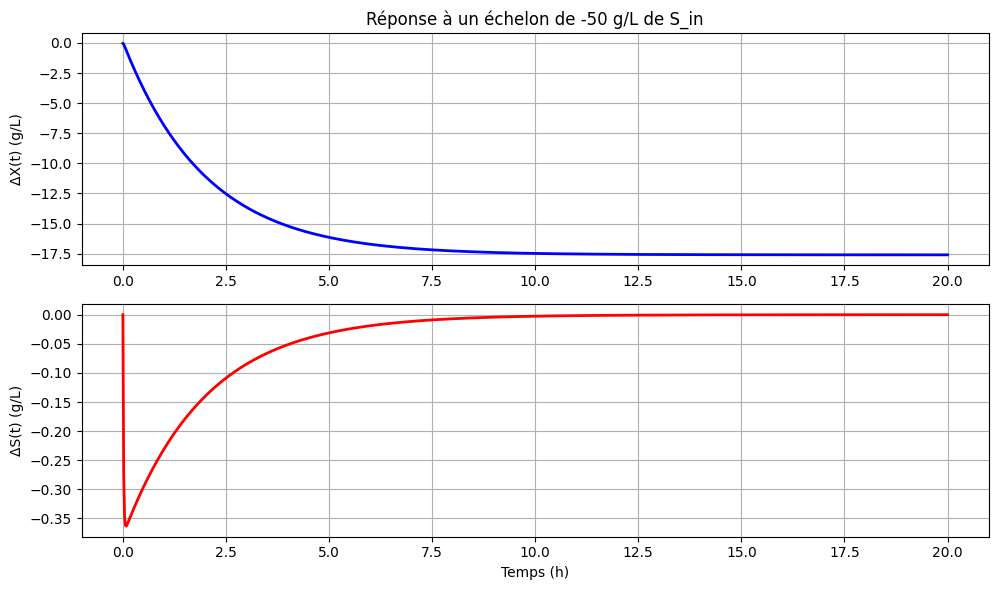

In [15]:
t = np.linspace(0, 20, 1000)
deltaX = -17.6 + 17.7*np.exp(-0.5*t) - 0.135*np.exp(-66.3*t)
deltaS = -0.38*np.exp(-0.5*t) + 0.38*np.exp(-66.3*t)

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, deltaX, 'b-', linewidth=2)
plt.ylabel('ΔX(t) (g/L)')
plt.title('Réponse à un échelon de -50 g/L de S_in')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, deltaS, 'r-', linewidth=2)
plt.ylabel('ΔS(t) (g/L)')
plt.xlabel('Temps (h)')
plt.grid(True)

plt.tight_layout()
plt.show()